# Checkpoint de Machine Learning — Energia

- **Parte 1 — Classificação:** prever a fonte de geração (Solar, Eólica ou Hidráulica) a partir de potência e localização (dados da ANEEL).
- **Parte 2 — Regressão:** estimar a radiação solar horizontal em Petrolina (PE) a partir de variáveis meteorológicas e da hora (Open-Meteo).

## Preparação do ambiente

In [ ]:
# ----- Manipulação de dados e gráficos -----
import csv
import json
import urllib.parse
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Preparação -----
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ----- Parte 1: classificadores -----
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ----- Parte 2: regressores -----
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ----- Métricas de classificação -----
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

# ----- Métricas de regressão -----
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42

---
# Parte 1 — Classificação da fonte de geração (ANEEL)

## 1. Carregamento e inspeção dos dados

In [2]:
url = 'https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv'
dados = pd.read_csv(url)
dados.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [3]:
print('Formato:', dados.shape)
print('\nTipos das colunas:')
print(dados.dtypes)
print('\nValores ausentes por coluna:')
print(dados.isna().sum())
print('\nLinhas duplicadas:', dados.duplicated().sum())

Formato: (3876, 4)

Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte              str
dtype: object

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Linhas duplicadas: 28


In [4]:
print('Contagem por classe:')
print(dados['fonte'].value_counts())
print('\nProporção por classe:')
print(dados['fonte'].value_counts(normalize=True).round(3))

Contagem por classe:
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64

Proporção por classe:
fonte
Hidráulica    0.381
Solar         0.310
Eólica        0.310
Name: proportion, dtype: float64


In [5]:
dados.describe().round(2)

,potencia_kw,latitude,longitude
count,3876.00,3876.00,3876.00
mean,42014.68,-12.69,-46.16
std,301636.59,9.50,8.36
min,0.16,-33.72,-69.94
25%,440.00,-21.14,-52.56
50%,12680.00,-10.47,-47.39
75%,30000.00,-4.13,-41.28
max,11233100.00,3.83,0.00


In [6]:
# Coordenadas (0, 0) ficam no oceano Atlântico: provável dado faltante preenchido com zero
sem_coord = (dados['latitude'] == 0) & (dados['longitude'] == 0)
print('Linhas com latitude = longitude = 0:', sem_coord.sum())
print(dados.loc[sem_coord, 'fonte'].value_counts())

Linhas com latitude = longitude = 0: 47
fonte
Eólica        24
Hidráulica    23
Name: count, dtype: int64


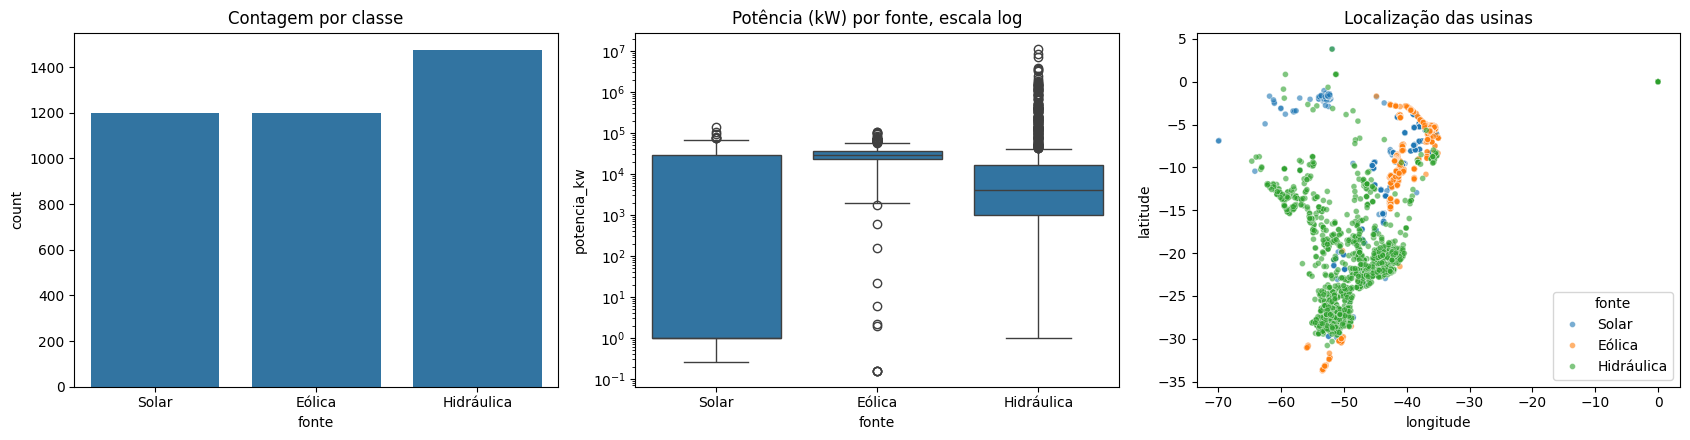

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.countplot(data=dados, x='fonte', ax=axes[0])
axes[0].set_title('Contagem por classe')

# Potência em escala logarítmica, pois varia de 0,16 kW a mais de 11 milhões de kW
sns.boxplot(data=dados, x='fonte', y='potencia_kw', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Potência (kW) por fonte, escala log')

sns.scatterplot(data=dados, x='longitude', y='latitude', hue='fonte', alpha=0.6, s=18, ax=axes[2])
axes[2].set_title('Localização das usinas')

plt.tight_layout()
plt.show()

### Entradas (`X`) e alvo (`y`)

- **`y` = `fonte`**: a classe a prever (Solar, Eólica ou Hidráulica). É um problema de classificação multiclasse.
- **`X`** tem três entradas numéricas:
  - `potencia_kw`: potência instalada da usina. Varia por ordens de grandeza e é muito assimétrica.
  - `latitude` e `longitude`: onde a usina está. Capturam padrões geográficos, como eólicas concentradas no litoral e no Nordeste e hidrelétricas ao longo de rios.
- Não usamos `SigTipoGeracao`, nomes, CEG ou descrições, pois entregariam a resposta e vazariam o alvo.

In [8]:
X = dados[['potencia_kw', 'latitude', 'longitude']]
y = dados['fonte']
print(X.shape, y.shape)

(3876, 3) (3876,)


## 2. Divisão estratificada em treino e teste (80% / 20%)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('\nProporção por classe (treino):')
print(y_train.value_counts(normalize=True).round(3))
print('\nProporção por classe (teste):')
print(y_test.value_counts(normalize=True).round(3))

Treino: (3100, 3) | Teste: (776, 3)

Proporção por classe (treino):
fonte
Hidráulica    0.381
Solar         0.310
Eólica        0.310
Name: proportion, dtype: float64

Proporção por classe (teste):
fonte
Hidráulica    0.381
Solar         0.309
Eólica        0.309
Name: proportion, dtype: float64


**Escala sem vazamento de dados:** o `StandardScaler` aprende média e desvio padrão dos dados. Por isso ele fica dentro de um `Pipeline`: no `fit` ele aprende só com o treino, e no `predict` apenas aplica o que aprendeu ao teste.

## 3. Os três classificadores

| Modelo | Por que foi escolhido | Precisa de escala? |
|---|---|---|
| **KNN** | Classifica pelos vizinhos mais próximos. Combina bem com latitude e longitude, já que usinas da mesma fonte tendem a ficar próximas. | Sim, pois usa distância |
| **Regressão Logística** | Modelo linear simples, serve de baseline. Mostra se uma fronteira linear já basta. | Sim, para convergir bem |
| **Random Forest** | Conjunto de árvores. Captura regras não lineares e interações (por exemplo, "potência alta e nessa região") e não sofre com a assimetria da potência. | Não, mas não prejudica |

In [10]:
modelos = {
    'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Regressão Logística': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED)),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=300, random_state=SEED)),
}

previsoes = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)            # escala aprendida só no treino
    previsoes[nome] = modelo.predict(X_test)
    print(f'{nome} treinado.')

KNN treinado.
Regressão Logística treinado.


Random Forest treinado.


## 4. Comparação das métricas
As métricas de Precision, Recall e F1 usam **`average='macro'`**: calcula-se a métrica de cada classe e tira-se a média simples, dando o mesmo peso a Solar, Eólica e Hidráulica, mesmo que tenham tamanhos diferentes.

In [11]:
linhas = []
for nome, y_pred in previsoes.items():
    linhas.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
    })

metricas = pd.DataFrame(linhas).set_index('Modelo').round(4)
metricas

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,
KNN,0.9652,0.9663,0.9636,0.9648
Regressão Logística,0.8247,0.8282,0.8214,0.8197
Random Forest,0.9755,0.9769,0.9741,0.9753


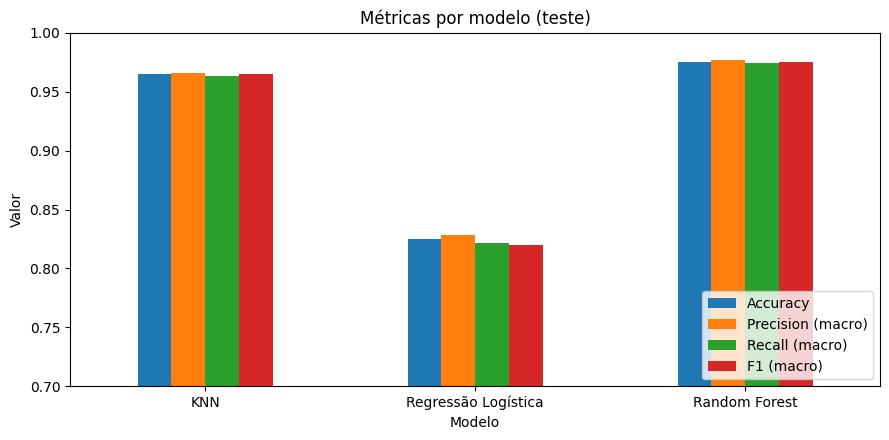

In [12]:
metricas.plot(kind='bar', figsize=(9, 4.5), ylim=(0.7, 1.0))
plt.title('Métricas por modelo (teste)')
plt.xticks(rotation=0)
plt.ylabel('Valor')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [13]:
# Métricas por classe de cada modelo
for nome, y_pred in previsoes.items():
    print(f'===== {nome} =====')
    print(classification_report(y_test, y_pred, digits=3))

===== KNN =====
              precision    recall  f1-score   support

      Eólica      0.971     0.963     0.967       240
  Hidráulica      0.954     0.986     0.970       296
       Solar      0.974     0.942     0.958       240

    accuracy                          0.965       776
   macro avg      0.966     0.964     0.965       776
weighted avg      0.965     0.965     0.965       776

===== Regressão Logística =====
              precision    recall  f1-score   support

      Eólica      0.753     0.900     0.820       240
  Hidráulica      0.871     0.868     0.870       296
       Solar      0.861     0.696     0.770       240

    accuracy                          0.825       776
   macro avg      0.828     0.821     0.820       776
weighted avg      0.831     0.825     0.823       776

===== Random Forest =====
              precision    recall  f1-score   support

      Eólica      0.971     0.979     0.975       240
  Hidráulica      0.964     0.993     0.978       296
 

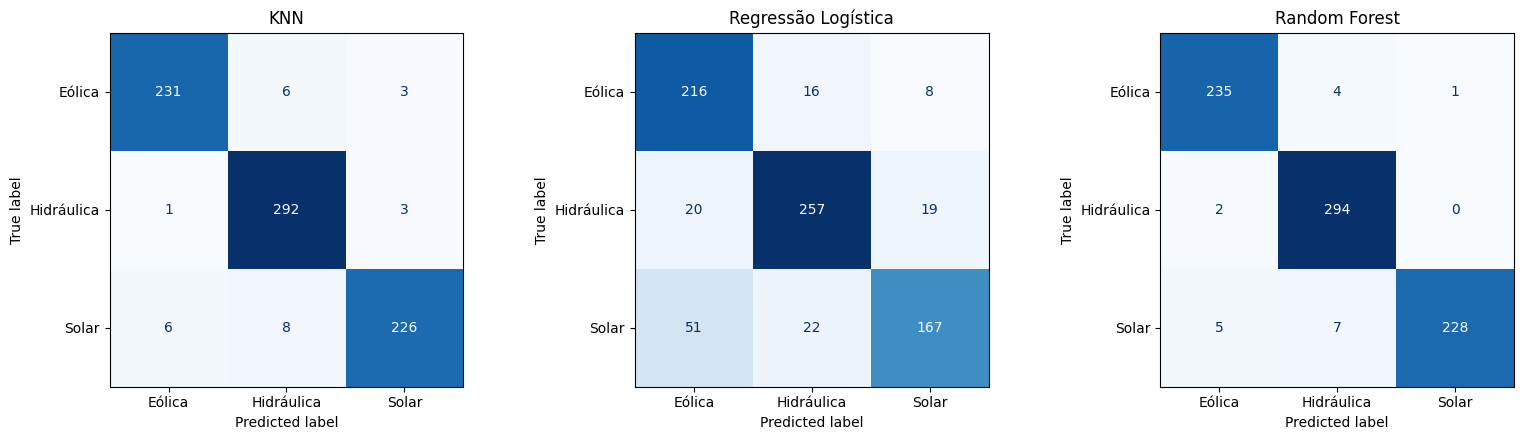

In [14]:
# Matrizes de confusão (linhas = classe real, colunas = classe prevista)
classes = sorted(y.unique())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nome, y_pred) in zip(axes, previsoes.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, labels=classes, cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(nome)
plt.tight_layout()
plt.show()

In [15]:
# Para a análise: quais confusões o melhor modelo comete
melhor = metricas['F1 (macro)'].idxmax()
cm = pd.DataFrame(confusion_matrix(y_test, previsoes[melhor], labels=classes),
                  index=[f'real {c}' for c in classes],
                  columns=[f'prev. {c}' for c in classes])
print('Melhor modelo:', melhor)
cm

Melhor modelo: Random Forest


,prev. Eólica,prev. Hidráulica,prev. Solar
real Eólica,235,4,1
real Hidráulica,2,294,0
real Solar,5,7,228


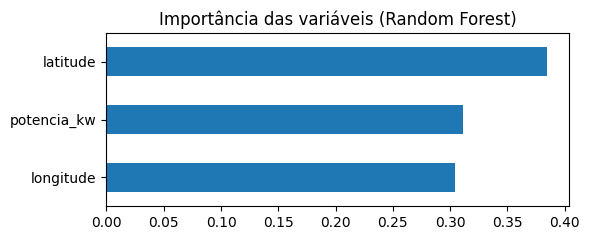

In [16]:
# Importância das variáveis no Random Forest
rf = modelos['Random Forest'].named_steps['randomforestclassifier']
pd.Series(rf.feature_importances_, index=X.columns).sort_values().plot(kind='barh', figsize=(6, 2.5))
plt.title('Importância das variáveis (Random Forest)')
plt.tight_layout()
plt.show()

In [17]:
# Comparação: KNN sem escala (o que você tinha antes) vs. com escala
knn_sem_escala = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
acc_sem = accuracy_score(y_test, knn_sem_escala.predict(X_test))
acc_com = accuracy_score(y_test, previsoes['KNN'])
print(f'KNN sem escala: {acc_sem:.4f}')
print(f'KNN com escala: {acc_com:.4f}')

KNN sem escala: 0.8724
KNN com escala: 0.9652


## 5. Análise e conclusão

**Modelo escolhido: Random Forest.** Foi o melhor em todas as métricas (Accuracy 0,976 e F1 macro 0,975), à frente do KNN (0,965 / 0,965) e bem acima da Regressão Logística (0,825 / 0,820). A diferença para o KNN é pequena (cerca de 8 usinas em 776), então os dois são candidatos razoáveis. Fico com o Random Forest porque erra menos, não depende de escala e mostra a importância das variáveis.

**O que cada resultado indica**
- A Regressão Logística ficou bem atrás porque a fronteira entre as fontes é geográfica e não linear (regiões e agrupamentos), e uma fronteira linear não consegue separá-las.
- O KNN sem escala teve acurácia de 0,872 contra 0,965 com escala. Sem padronizar, `potencia_kw` (de 0,16 a mais de 11 milhões) dominava a distância e as coordenadas quase não contavam.

**Classes mais confundidas (Random Forest)**
- **Solar é a mais difícil:** recall de 0,950. Das 240 usinas solares no teste, 7 foram previstas como Hidráulica e 5 como Eólica.
- **Hidráulica** tem recall alto (0,993), mas isso vem em parte de ela ser a classe maior e de receber os erros das outras: 4 eólicas e 7 solares foram classificadas como hidráulicas.
- **Eólica ↔ Hidráulica** também se confunde um pouco (4 eólicas previstas como hidráulicas). Pelos dados, ambas têm potências grandes e se sobrepõem na faixa de potência.

**Por que potência e localização podem não bastar numa aplicação real**
1. **Sobreposição:** uma usina solar de 30 MW, uma eólica de 30 MW e uma PCH (hidrelétrica pequena) têm a mesma potência. Se também estiverem na mesma região, os dados não as distinguem.
2. **Qualidade da localização:** 47 registros têm latitude e longitude iguais a 0 (provável dado faltante). O modelo pode acabar aprendendo "coordenada zero = eólica ou hidráulica" (24 e 23 casos), um atalho que só existe neste dataset.
3. **Generalização geográfica:** a divisão é aleatória, então usinas vizinhas caem em treino e teste e facilitam o acerto. Para uma região ou estado novo, o desempenho tende a ser menor. Vale testar com validação por região.
4. **Poucas variáveis:** a importância no Random Forest é distribuída (latitude 0,38, potência 0,31, longitude 0,31), ou seja, o modelo usa as três juntas. Para uso real, faltam informações como altitude, distância de rios ou litoral, irradiação e velocidade do vento.
5. **Custo dos erros:** além de ver a acurácia geral, é preciso decidir qual erro é pior (por exemplo, tratar uma solar como hidráulica) e avaliar com mais dados e validação cruzada.

---
# Parte 2 — Regressão da radiação solar em Petrolina (PE)

**Pergunta:** dadas as condições meteorológicas e a hora local, qual é a radiação solar horizontal média naquela hora? A resposta é um número (W/m²), então o problema é de **regressão**.

Os dados vêm da API histórica do Open-Meteo (1º de abril a 30 de junho de 2025, horário local). São valores estimados por modelos/reanálise, não leituras de um sensor.

## 1. Consulta à API do Open-Meteo

In [ ]:
def consultar_api(url, parametros):
    """Faz um GET com os parâmetros e devolve o JSON da resposta."""
    url_completa = f"{url}?{urllib.parse.urlencode(parametros)}"
    req = urllib.request.Request(url_completa, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=60) as resposta:
        return json.loads(resposta.read().decode('utf-8'))


URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                        "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")

horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

## 2. Gerar o CSV horário (7h às 17h)
As listas de `hourly` são alinhadas por índice. Mantemos só as horas de 7h a 17h e descartamos linhas com valor ausente, contando quantas foram descartadas.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]

linhas_regressao = []
horas_no_recorte = 0
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    if not (7 <= hora <= 17):
        continue
    horas_no_recorte += 1
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])

if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")

print("Horas entre 7h e 17h:", horas_no_recorte)
print("Horas válidas:", len(linhas_regressao))
print("Descartadas por valor ausente:", horas_no_recorte - len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

## 3. Carregar o CSV e entender as colunas

| Coluna | Significado | Papel |
|---|---|---|
| `data_hora` | Data e hora local do registro | Ordena e separa treino/teste; **não** é entrada |
| `temperatura_c` | Temperatura do ar a 2 m (°C) | Entrada |
| `umidade_pct` | Umidade relativa a 2 m (%) | Entrada |
| `nuvens_pct` | Cobertura total de nuvens (%) | Entrada |
| `vento_kmh` | Velocidade do vento a 10 m (km/h) | Entrada |
| `hora` | Hora local (7 a 17) | Entrada |
| `radiacao_w_m2` | Radiação global horizontal média da hora anterior (W/m²) | **Alvo `y`** |

In [ ]:
df = pd.read_csv("meteo_regressao_orange.csv", parse_dates=["data_hora"])
df = df.sort_values("data_hora").reset_index(drop=True)   # garante a ordem temporal
df.head()

In [ ]:
print("Formato:", df.shape)
print("Período:", df["data_hora"].min(), "->", df["data_hora"].max())
print("\nTipos das colunas:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())
print("\nLinhas duplicadas em data_hora:", df["data_hora"].duplicated().sum())

In [ ]:
df.describe().round(2)

## 4. Visualização exploratória

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Radiação por hora do dia
sns.boxplot(data=df, x="hora", y="radiacao_w_m2", ax=axes[0], color="skyblue")
axes[0].set_title("Radiação por hora do dia")
axes[0].set_xlabel("Hora local")
axes[0].set_ylabel("Radiação (W/m²)")

# Radiação x nuvens
sns.scatterplot(data=df, x="nuvens_pct", y="radiacao_w_m2", hue="hora",
                palette="viridis", alpha=0.6, s=18, ax=axes[1])
axes[1].set_title("Radiação x cobertura de nuvens")
axes[1].set_xlabel("Nuvens (%)")
axes[1].set_ylabel("Radiação (W/m²)")

# Correlação
sns.heatmap(df.drop(columns="data_hora").corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[2])
axes[2].set_title("Correlação entre as variáveis")

plt.tight_layout()
plt.show()

**Como ler:** a radiação tem forma de sino ao longo do dia (baixa às 7h, pico perto do meio-dia, queda à tarde), então a relação com `hora` **não é linear**. Já as nuvens reduzem a radiação em cada hora. Confira nos gráficos acima se isso aparece nos seus dados.

## 5. Definição de `X` e `y`

- **`X`** (cinco entradas): `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh` e `hora`.
- **`y`**: `radiacao_w_m2`.
- `data_hora` fica de fora (serve só para ordenar) e nenhum valor de `radiacao_w_m2` é usado para criar uma entrada do mesmo registro.

In [ ]:
colunas_x = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X = df[colunas_x]
y = df["radiacao_w_m2"]
print(X.shape, y.shape)

## 6. Divisão temporal: 80% iniciais para treino, 20% finais para teste
Sem embaralhar: o modelo treina no passado e é testado no futuro, como seria numa aplicação real.

In [ ]:
corte = int(len(df) * 0.8)

X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]

print("Treino:", X_train.shape, "|", df["data_hora"].iloc[0].date(), "->", df["data_hora"].iloc[corte - 1].date())
print("Teste: ", X_test.shape, "|", df["data_hora"].iloc[corte].date(), "->", df["data_hora"].iloc[-1].date())

## 7. Os três algoritmos

| Algoritmo | Por que foi escolhido | Escala? |
|---|---|---|
| **Regressão Linear Múltipla** | Baseline simples e interpretável. Mostra o que uma relação linear consegue explicar. | Sim (dentro de um `Pipeline`, ajustada só no treino) |
| **Random Forest Regressor** | Conjunto de árvores; captura relações não lineares e interações (por exemplo, hora × nuvens) sem precisar de escala. | Não |
| **Gradient Boosting Regressor** | Árvores construídas em sequência, cada uma corrigindo o erro da anterior; costuma ser muito forte em dados tabulares. | Não |

Todos usam a **mesma divisão** do passo anterior.

In [ ]:
modelos = {
    "Regressão Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=SEED),
}

previsoes = {}
linhas = []
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)               # escala (se houver) aprendida só no treino
    y_pred = modelo.predict(X_test)
    previsoes[nome] = y_pred
    mse = mean_squared_error(y_test, y_pred)
    linhas.append({
        "Algoritmo": nome,
        "MAE (W/m²)": mean_absolute_error(y_test, y_pred),
        "MSE ((W/m²)²)": mse,
        "RMSE (W/m²)": np.sqrt(mse),
        "R²": r2_score(y_test, y_pred),
    })

tabela = pd.DataFrame(linhas).set_index("Algoritmo").round(3)
tabela

## 8. Valores reais × previstos

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
limite = max(y_test.max(), max(p.max() for p in previsoes.values()))

for ax, (nome, y_pred) in zip(axes, previsoes.items()):
    ax.scatter(y_test, y_pred, alpha=0.5, s=18)
    ax.plot([0, limite], [0, limite], "r--", label="Ideal (previsto = real)")
    ax.set_title(f"{nome}  (R² = {tabela.loc[nome, 'R²']:.3f})")
    ax.set_xlabel("Radiação real (W/m²)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Radiação prevista (W/m²)")
axes[0].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Primeiros 5 dias do teste (horas diurnas em sequência, sem as noites)
n = 11 * 5
x = np.arange(n)
plt.figure(figsize=(14, 4.5))
plt.plot(x, y_test.iloc[:n].values, color="black", lw=2, label="Real")
for nome, y_pred in previsoes.items():
    plt.plot(x, y_pred[:n], lw=1.3, alpha=0.85, label=nome)
plt.xlabel("Horas de teste em sequência (7h a 17h de cada dia; 11 por dia)")
plt.ylabel("Radiação (W/m²)")
plt.title("Real x previsto nos primeiros 5 dias do teste")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Onde os erros acontecem e o peso da hora

In [ ]:
melhor = tabela["MAE (W/m²)"].idxmin()
print("Modelo com menor MAE:", melhor)

erros = pd.DataFrame({
    "hora": X_test["hora"].values,
    "erro_abs": np.abs(y_test.values - previsoes[melhor]),
    "erro": previsoes[melhor] - y_test.values,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
erros.groupby("hora")["erro_abs"].mean().plot(kind="bar", ax=axes[0], color="tab:orange")
axes[0].set_title(f"MAE por hora do dia ({melhor})")
axes[0].set_ylabel("MAE (W/m²)")
axes[0].set_xlabel("Hora local")

axes[1].hist(erros["erro"], bins=40, color="tab:blue", alpha=0.8)
axes[1].axvline(0, color="r", ls="--")
axes[1].set_title("Distribuição do erro (previsto − real)")
axes[1].set_xlabel("Erro (W/m²)")
plt.tight_layout()
plt.show()

In [ ]:
# Importância das variáveis (árvores) e coeficientes padronizados (linear)
imp = pd.DataFrame({
    "Random Forest": modelos["Random Forest"].feature_importances_,
    "Gradient Boosting": modelos["Gradient Boosting"].feature_importances_,
}, index=colunas_x)
coef = pd.Series(modelos["Regressão Linear"][-1].coef_, index=colunas_x, name="Coef. linear (padronizado)")

print("Importância das variáveis nos modelos de árvores:")
print(imp.round(3))
print("\nCoeficientes da Regressão Linear (entradas padronizadas):")
print(coef.round(2))

In [ ]:
# Quanto a hora pesa? Retreina Random Forest e Regressão Linear sem a coluna 'hora'
sem_hora = [c for c in colunas_x if c != "hora"]
comparacao = []
for nome, base in [("Random Forest", RandomForestRegressor(n_estimators=200, random_state=SEED)),
                   ("Regressão Linear", make_pipeline(StandardScaler(), LinearRegression()))]:
    base.fit(X_train[sem_hora], y_train)
    p = base.predict(X_test[sem_hora])
    comparacao.append({
        "Modelo": nome,
        "MAE com hora": tabela.loc[nome, "MAE (W/m²)"],
        "MAE sem hora": mean_absolute_error(y_test, p),
        "R² com hora": tabela.loc[nome, "R²"],
        "R² sem hora": r2_score(y_test, p),
    })
pd.DataFrame(comparacao).set_index("Modelo").round(3)

## 10. Resumo automático dos resultados

In [ ]:
pior_hora = erros.groupby("hora")["erro_abs"].mean().idxmax()
media_teste = y_test.mean()
print(f"Melhor modelo (menor MAE): {melhor}")
print(f"  MAE = {tabela.loc[melhor, 'MAE (W/m²)']:.1f} W/m² "
      f"({100 * tabela.loc[melhor, 'MAE (W/m²)'] / media_teste:.1f}% da radiação média do teste, {media_teste:.0f} W/m²)")
print(f"  RMSE = {tabela.loc[melhor, 'RMSE (W/m²)']:.1f} W/m²  |  R² = {tabela.loc[melhor, 'R²']:.3f}")
print(f"  Hora com maior erro médio: {pior_hora}h")
print(f"  Viés médio (previsto − real): {erros['erro'].mean():+.1f} W/m²")

## 11. Interpretação

> Complete os trechos marcados com **[ ]** usando os números do resumo e das tabelas acima. O restante é a discussão conceitual pedida.

**Comparação dos modelos.** O melhor modelo foi **[ ]**, com MAE de **[ ]** W/m² e R² de **[ ]**. Compare com a Regressão Linear (MAE **[ ]**, R² **[ ]**): se a diferença for grande, indica que a relação entre as variáveis e a radiação não é linear. O MAE está na unidade do alvo e diz o erro médio típico; o MSE e o RMSE penalizam mais os erros grandes, e se o RMSE for bem maior que o MAE existem horas com erro muito acima do normal.

**Onde o modelo erra.** O gráfico de MAE por hora mostra em quais horas o erro é maior. Em geral os maiores erros aparecem perto do meio-dia, onde a radiação é alta, e em dias de nuvens parciais, em que a cobertura média de uma hora não diz se o sol estava coberto naquele momento. O viés médio indica se o modelo tende a superestimar ou subestimar.

**Peso da hora.** A radiação em um local depende fortemente da posição do sol, que varia com a hora, então `hora` costuma ser a variável mais importante. Veja a tabela de importâncias e o teste sem a coluna `hora`: se o erro aumenta muito ao tirá-la, a hora carrega a maior parte da informação. A Regressão Linear lida mal com ela porque a relação é em forma de sino, e não uma reta, o que favorece os modelos de árvores.

**Limites da divisão temporal.** O teste cobre as últimas semanas de junho e o treino vai de abril a meados de junho. Se o clima mudou nesse intervalo (início da estação seca, menos nuvens), o modelo é testado em condições um pouco diferentes das que viu. É uma avaliação mais realista que a aleatória, mas com apenas três meses de dados.

**Por que isso não prevê a energia de um sistema fotovoltaico.**
1. **Radiação não é energia:** W/m² é potência por área num instante (média da hora). Energia em kWh exige multiplicar pela área e pelo tempo.
2. **A radiação é horizontal:** os painéis são inclinados e orientados, e o plano deles recebe uma quantidade diferente.
3. **Eficiência e perdas:** o rendimento do painel, do inversor, da fiação, a sujeira e a temperatura do módulo (que reduz a eficiência) mudam a geração final.
4. **Sombras e instalação real:** sombreamento, degradação do equipamento e limites do inversor não aparecem nos dados.
5. **Dados de modelo:** os valores vêm de reanálise e não de um sensor no local, e as nuvens são a média da hora.

Para estimar geração seria preciso, no mínimo, converter a radiação para o plano do painel e aplicar um modelo de desempenho do sistema, ou treinar com a geração medida do próprio equipamento.